# Model Preparation 04 — Baseline Models

**Goal:** Implement and measure the simplest possible price prediction models.
Every more complex model (XGBoost, LightGBM, neural networks) must beat these baselines.
If it does not, something is wrong with the model or the data.

**Tables:** gold_price_features, gold_card_features

**Models:**
1. **Naive** — prediction = last known price (log-return = 0)
2. **MA7d** — prediction = 7-day moving average
3. **AR(1)** — autoregression on lag-1 log-returns
4. **Ridge** — linear regression with card features + price history

**Metrics** (all reported separately per tier):
- **MAE** on log-return scale — robust to outliers
- **RMSE** on log-return scale — penalises large errors
- **MAE (€)** — absolute error in EUR, more interpretable for the business

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import json

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

with open("validation_config.json") as f:
    validation_cfg = json.load(f)
with open("feature_sets.json") as f:
    feature_sets = json.load(f)
with open("leakage_config.json") as f:
    leakage_cfg = json.load(f)

print("Configuration loaded:")
print(f"  validation_config: status={validation_cfg['status']}")
print(
    f"  feature_sets:      tier1={len(feature_sets['tier1'])} features, tier3={len(feature_sets['tier3'])} features"
)
print(f"  leakage_config:    {len(leakage_cfg['leakage'])} leakage columns")

Configuration loaded:
  validation_config: status=ACTIVE
  feature_sets:      tier1=9 features, tier3=8 features
  leakage_config:    3 leakage columns


## 1. Naive Baseline — Prediction = Last Known Price

**Mathematical form:** `pred_log_return_7d = 0`  
**Equivalent in price space:** `pred_EUR_{t+7} = EUR_t`

**Why this matters:** The Naive model is the simplest possible sensible predictor. It says
"the price will not change." Any more complex model must outperform it — if it cannot,
it adds no value over doing nothing.

**MAPE warning:** Mean Absolute Percentage Error divides by the actual price. For bulk cards
(€0.02) this produces extreme values. Use MAE in EUR as the primary interpretable metric.

**Current status:** 1,954,717 of 2,935,566 rows have a t+7 target (66.6%). Of those,
1,635,819 rows fall before the locked test-set cutoff (2026-06-18) and are used to fit/
evaluate the in-sample baselines below.

In [3]:
# Load full history with date-exact t+7 target JOIN.
# Tier is assigned per row based on eur_t0 (price at prediction time, not future price).
df_full = gold.execute("""
    SELECT
        p.uuid, p.snapshot_date, p.eur AS eur_t0,
        p7.eur AS eur_t7,
        LOG(p7.eur + 0.01) - LOG(p.eur + 0.01) AS target_logreturn_7d,
        p.price_7d_avg,
        CASE
            WHEN p.eur < 100   THEN 'Tier1'
            WHEN p.eur <= 1000 THEN 'Tier2'
            ELSE                'Tier3'
        END AS tier
    FROM gold_price_features p
    LEFT JOIN gold_price_features p7
        ON p.uuid = p7.uuid
        AND CAST(p7.snapshot_date AS DATE)
            = CAST(p.snapshot_date AS DATE) + INTERVAL '7' DAY
    WHERE p.eur IS NOT NULL AND p.uuid IS NOT NULL
""").df()
df_full["snapshot_date"] = pd.to_datetime(df_full["snapshot_date"])

n_total = len(df_full)
n_with_t7 = df_full["target_logreturn_7d"].notna().sum()
print(f"Total rows: {n_total:,}   |   Rows with t+7 target: {n_with_t7:,}")


def compute_metrics(y_true_arr, y_pred_arr, eur_t0_arr, label, tier=None):
    """Compute MAE/RMSE on log-return scale and MAE in EUR for one model+tier combination."""
    y_true_arr = np.asarray(y_true_arr)
    y_pred_arr = np.asarray(y_pred_arr)
    eur_t0_arr = np.asarray(eur_t0_arr)
    if len(y_true_arr) == 0:
        return {
            "model": label,
            "tier": tier or "All",
            "n": 0,
            "MAE_logr": None,
            "RMSE_logr": None,
            "MAE_EUR": None,
        }
    eur_pred = np.expm1(np.log1p(eur_t0_arr) + y_pred_arr)
    eur_actual = np.expm1(np.log1p(eur_t0_arr) + y_true_arr)
    return {
        "model": label,
        "tier": tier or "All",
        "n": len(y_true_arr),
        "MAE_logr": round(float(np.mean(np.abs(y_true_arr - y_pred_arr))), 5),
        "RMSE_logr": round(float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2))), 5),
        "MAE_EUR": round(float(np.mean(np.abs(eur_actual - eur_pred))), 4),
    }


# Train set: all rows with a t+7 target, before the hold-out test period.
# If validation_config is DEFERRED use all available data.
test_start = validation_cfg.get("test_start")
if validation_cfg["status"] == "DEFERRED" or test_start is None:
    train_df = df_full.dropna(subset=["target_logreturn_7d"]).copy()
else:
    train_df = (
        df_full[df_full["snapshot_date"] < pd.Timestamp(test_start)]
        .dropna(subset=["target_logreturn_7d"])
        .copy()
    )

results = []  # accumulate metrics across all models

if len(train_df) == 0:
    n_snap = gold.execute(
        "SELECT COUNT(DISTINCT snapshot_date) FROM gold_price_features"
    ).fetchone()[0]
    print(f"\n⚠  No t+7 target rows — {n_snap} snapshot(s) available (need ≥8).")
    print("   All baseline metrics are deferred.")
    print(
        "   The code is complete; metrics will populate automatically at ≥8 snapshots."
    )
else:
    y_true = train_df["target_logreturn_7d"].values
    eur_t0 = train_df["eur_t0"].values
    tiers = train_df["tier"].values

    # Naive: log-return = 0 (predict no price change).
    pred_naive = np.zeros(len(train_df))

    for tier_filter in [None, "Tier1", "Tier2", "Tier3"]:
        mask = (
            np.ones(len(train_df), dtype=bool)
            if tier_filter is None
            else (tiers == tier_filter)
        )
        results.append(
            compute_metrics(
                y_true[mask], pred_naive[mask], eur_t0[mask], "Naive", tier_filter
            )
        )

    print("\n=== NAIVE BASELINE ===")
    display(pd.DataFrame([r for r in results if r["model"] == "Naive"]))

Total rows: 2,935,566   |   Rows with t+7 target: 1,954,717



=== NAIVE BASELINE ===


,model,tier,n,MAE_logr,RMSE_logr,MAE_EUR
0,Naive,All,1635819,0.0,0.0,0.0
1,Naive,Tier1,1621734,0.0,0.0,0.0
2,Naive,Tier2,11305,0.0,0.0,0.0
3,Naive,Tier3,2780,0.0,0.0,0.0


## 2. MA7d Baseline — 7-Day Moving Average

**Prediction:** `pred_EUR_{t+7} = price_7d_avg`

**Signal interpretation:**
- MA7d **beats Naive** → prices exhibit **mean reversion** (they drift back towards the average)
- MA7d **loses to Naive** → prices have **momentum** (the most recent price is the best predictor)

This determination directly influences model design:
- Mean-reverting market → include 7-day average as a feature; consider mean-reversion models
- Momentum market → include lag-1 log-return; consider trend-following models

**Business insight:** If MA7d beats Naive for Tier 3 but not Tier 1 → expensive and cheap cards
have different dynamics, reinforcing the tier-segmented model design.

In [4]:
if len(train_df) == 0:
    print("⚠  No t+7 target data — MA7d baseline deferred.")
    print(
        "   Interpretation: MA7d MAE < Naive MAE → mean reversion; MA7d > Naive → momentum."
    )
else:
    # Convert price_7d_avg back to a log-return relative to eur_t0.
    # Fill missing price_7d_avg with eur_t0 — equivalent to the Naive prediction for new cards.
    avg_prices = train_df["price_7d_avg"].fillna(train_df["eur_t0"]).values
    pred_ma7d = np.log1p(avg_prices) - np.log1p(eur_t0)

    for tier_filter in [None, "Tier1", "Tier2", "Tier3"]:
        mask = (
            np.ones(len(train_df), dtype=bool)
            if tier_filter is None
            else (tiers == tier_filter)
        )
        results.append(
            compute_metrics(
                y_true[mask], pred_ma7d[mask], eur_t0[mask], "MA7d", tier_filter
            )
        )

    print("=== MA7d BASELINE ===")
    display(pd.DataFrame([r for r in results if r["model"] == "MA7d"]))

    # Summarise: does MA7d improve over Naive per tier?
    print("\nMA7d vs Naive (lower MAE_logr = better):")
    naive_by_tier = {r["tier"]: r["MAE_logr"] for r in results if r["model"] == "Naive"}
    ma7d_by_tier = {r["tier"]: r["MAE_logr"] for r in results if r["model"] == "MA7d"}
    for tier in ["All", "Tier1", "Tier2", "Tier3"]:
        n_mae = naive_by_tier.get(tier)
        m_mae = ma7d_by_tier.get(tier)
        if n_mae and m_mae:
            dynamic = "mean reversion ✓" if m_mae < n_mae else "momentum (Naive wins)"
            print(f"  {tier:6s}: Naive={n_mae:.5f}, MA7d={m_mae:.5f} → {dynamic}")

=== MA7d BASELINE ===


,model,tier,n,MAE_logr,RMSE_logr,MAE_EUR
0,MA7d,All,1635819,0.0,0.0,0.000
1,MA7d,Tier1,1621734,0.0,0.0,0.000
2,MA7d,Tier2,11305,0.0,0.0,0.000
3,MA7d,Tier3,2780,0.0,0.0,0.001



MA7d vs Naive (lower MAE_logr = better):


## 3. AR(1) — First-Order Autoregression

**Model:** `log_return_t = α + β × log_return_{t−1} + ε`

**Why AR(1):** If Ljung-Box tests (statistical_properties/02) detect lag-1 autocorrelation in
log-returns, AR(1) should exploit it and outperform Naive. If it does not — either the
autocorrelation is too weak to be practically useful, or non-stationarity is masking the signal.

**Pooled model:** A single AR(1) trained across all cards, which assumes the autocorrelation
structure is homogeneous. This is a simplification appropriate for a baseline.

**Coefficient interpretation:**
- β ≈ 0 → no autocorrelation, Naive is optimal
- β > 0.1 → positive momentum (recent gain predicts future gain)
- β < −0.1 → mean reversion (recent gain predicts future pullback)

**Key constraint:** Lag-1 log-returns are constructed *within* each card's time series.
Shifting across cards (mixing different series) would introduce spurious autocorrelation.

In [5]:
if len(train_df) == 0:
    print("⚠  No t+7 target data — AR(1) baseline deferred.")
    print(
        "   Positive β → momentum; negative β → mean reversion; |β| < 0.1 → no useful signal."
    )
else:
    # Compute lag-1 log-return within each card's series (sort by uuid + date, then shift).
    df_sorted = df_full.sort_values(["uuid", "snapshot_date"]).copy()
    df_sorted["lag1_logreturn"] = df_sorted.groupby("uuid")[
        "target_logreturn_7d"
    ].shift(1)

    train_ar = train_df.merge(
        df_sorted[["uuid", "snapshot_date", "lag1_logreturn"]],
        on=["uuid", "snapshot_date"],
        how="left",
    ).dropna(subset=["lag1_logreturn", "target_logreturn_7d"])

    if len(train_ar) < 10:
        print(f"⚠  Only {len(train_ar)} rows with lag-1 data — AR(1) not reliable yet.")
        print("   Minimum ~50 observations recommended for a stable OLS estimate.")
    else:
        X_ar = train_ar["lag1_logreturn"].values.reshape(-1, 1)
        y_ar = train_ar["target_logreturn_7d"].values

        ar1 = LinearRegression().fit(X_ar, y_ar)
        pred_ar1 = ar1.predict(X_ar)

        beta = ar1.coef_[0]
        print(f"AR(1): α={ar1.intercept_:.5f}, β={beta:.5f}")
        if abs(beta) < 0.1:
            print(
                f"  β interpretation: |β|={abs(beta):.3f} < 0.1 → weak autocorrelation"
            )
        elif beta > 0:
            print(f"  β interpretation: β={beta:.3f} > 0 → positive momentum")
        else:
            print(f"  β interpretation: β={beta:.3f} < 0 → mean reversion")

        ar_tiers = train_ar["tier"].values
        ar_eur = train_ar["eur_t0"].values
        for tier_filter in [None, "Tier1", "Tier2", "Tier3"]:
            mask = (
                np.ones(len(train_ar), dtype=bool)
                if tier_filter is None
                else (ar_tiers == tier_filter)
            )
            results.append(
                compute_metrics(
                    y_ar[mask], pred_ar1[mask], ar_eur[mask], "AR(1)", tier_filter
                )
            )

        print("\n=== AR(1) BASELINE ===")
        display(pd.DataFrame([r for r in results if r["model"] == "AR(1)"]))

AR(1): α=0.00000, β=0.00000
  β interpretation: |β|=0.000 < 0.1 → weak autocorrelation



=== AR(1) BASELINE ===


,model,tier,n,MAE_logr,RMSE_logr,MAE_EUR
0,AR(1),All,1470144,0.0,0.0,0.0
1,AR(1),Tier1,1457470,0.0,0.0,0.0
2,AR(1),Tier2,10172,0.0,0.0,0.0
3,AR(1),Tier3,2502,0.0,0.0,0.0


## 4. Ridge Regression with Domain Features

**Model:** `log_return_{7d} = α + Σ βᵢ xᵢ + ε`  with L2 regularisation (alpha = 1.0)

**Why Ridge instead of OLS:** Multicollinear features (e.g., `is_legacy_legal` and `format_count`)
inflate OLS coefficient variance. Ridge shrinks coefficients towards zero, giving a more stable
model. Alpha = 1.0 is a conservative starting point; tune with CV once data is available.

**Pipeline:**
1. Impute: booleans → 0.0 (Scryfall-only = False); numerics → median
2. Scale: `StandardScaler` fit on training data only (never on validation or test)
3. Fit: `Ridge(alpha=1.0)`

**Key invariant:** The scaler must be fit exclusively on the training split. Applying the fitted
scaler to validation/test is correct — fitting it there would be preprocessing leakage.

In [6]:
if len(train_df) == 0:
    print("⚠  No t+7 target data — Ridge baseline deferred.")
else:
    # Load card features and join to the training rows.
    cf = gold.execute("""
        SELECT uuid, rarity, mana_value, is_reserved, is_reprint, is_promo,
               is_full_art, is_textless, edhrec_saltiness, finish_count, has_etched_finish,
               color_count, color_identity_count, variation_count,
               is_commander_legal, is_standard_legal, is_modern_legal, is_legacy_legal,
               format_count, print_count
        FROM gold_card_features
    """).df()

    train_feat = train_df.merge(cf, on="uuid", how="left")

    # Use only features that exist in this dataframe (guards against schema evolution).
    features = [f for f in feature_sets["tier1"] if f in train_feat.columns]
    print(f"Features used ({len(features)}): {features}")

    X_train = train_feat[features].copy()
    bool_cols = X_train.select_dtypes(include="bool").columns
    X_train[bool_cols] = X_train[bool_cols].astype(float)
    # Fill NULLs with column median — production pipeline uses per-rarity median, but
    # column median is sufficient here for a simple baseline comparison.
    X_train = X_train.fillna(X_train.median(numeric_only=True))
    X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)

    y_train = train_feat["target_logreturn_7d"].values

    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=1.0)),
        ]
    )
    pipe.fit(X_train, y_train)
    pred_ridge = pipe.predict(X_train)

    ridge_tiers = train_feat["tier"].values
    ridge_eur = train_feat["eur_t0"].values
    for tier_filter in [None, "Tier1", "Tier2", "Tier3"]:
        mask = (
            np.ones(len(train_feat), dtype=bool)
            if tier_filter is None
            else (ridge_tiers == tier_filter)
        )
        results.append(
            compute_metrics(
                y_train[mask], pred_ridge[mask], ridge_eur[mask], "Ridge", tier_filter
            )
        )

    coef_df = pd.DataFrame(
        {
            "feature": features,
            "coefficient": pipe.named_steps["ridge"].coef_,
        }
    ).sort_values("coefficient", key=abs, ascending=False)
    print(
        "\nTop Ridge coefficients (on standardised features — larger |value| = more influence):"
    )
    display(coef_df.head(10))

    print("\n=== RIDGE BASELINE ===")
    display(pd.DataFrame([r for r in results if r["model"] == "Ridge"]))

Features used (5): ['edhrec_saltiness', 'format_count', 'is_full_art', 'print_count', 'variation_count']



Top Ridge coefficients (on standardised features — larger |value| = more influence):


,feature,coefficient
0,edhrec_saltiness,0.0
1,format_count,0.0
2,is_full_art,0.0
3,print_count,0.0
4,variation_count,0.0



=== RIDGE BASELINE ===


,model,tier,n,MAE_logr,RMSE_logr,MAE_EUR
0,Ridge,All,1635819,0.0,0.0,0.0
1,Ridge,Tier1,1621734,0.0,0.0,0.0
2,Ridge,Tier2,11305,0.0,0.0,0.0
3,Ridge,Tier3,2780,0.0,0.0,0.0


## 5. Benchmark Table and Visualisation

The consolidated benchmark. Every future model (XGBoost, LightGBM, neural network) must beat
the best baseline shown here — otherwise it adds no value.

**Interpretation guide:**
- Naive MAE is the **floor for model utility** — a model worse than Naive is useless
- MAE Tier1 in EUR: for a card priced at €1, this is how many cents the model is off on average
- MAE Tier3 in EUR: for a card priced at €2000, this is the absolute error in euros

**On training MAE vs validation MAE:** These numbers are computed on the training set
(the only data available now). They represent in-sample fit, not out-of-sample generalisation.
The true benchmark will be computed on the validation folds and test set once data arrives.

=== BASELINE BENCHMARK (in-sample — training data only) ===

MAE (log-return scale):


model,AR(1),MA7d,Naive,Ridge
tier,,,,
All,0.0,0.0,0.0,0.0
Tier1,0.0,0.0,0.0,0.0
Tier2,0.0,0.0,0.0,0.0
Tier3,0.0,0.0,0.0,0.0



MAE (EUR — interpretable scale):


model,AR(1),MA7d,Naive,Ridge
tier,,,,
All,0.0,0.000,0.0,0.0
Tier1,0.0,0.000,0.0,0.0
Tier2,0.0,0.000,0.0,0.0
Tier3,0.0,0.001,0.0,0.0


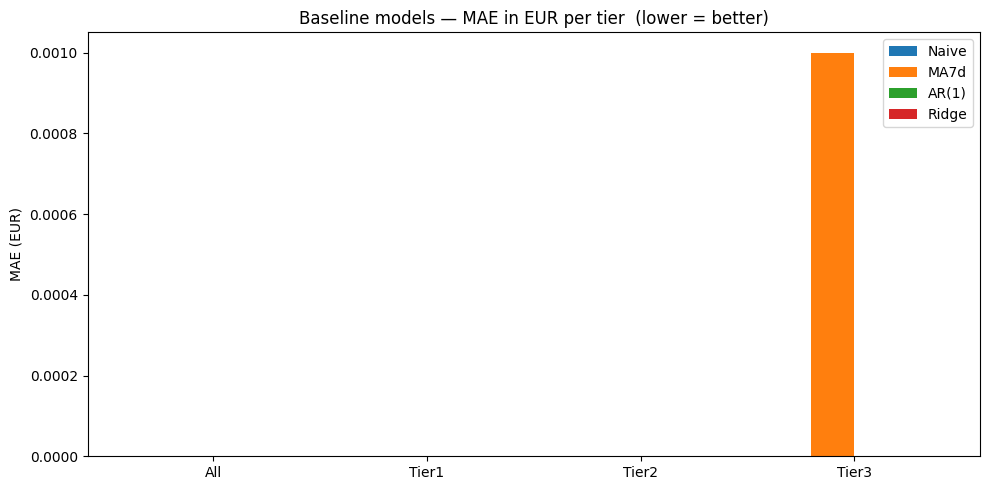


Saved baseline_benchmark.csv ✓


In [7]:
if len(results) == 0:
    print("No results — all models deferred (0 rows with t+7 target data).")
    print()
    print("Expected benchmark table once ≥8 snapshots exist:")
    dummy_models = ["Naive", "MA7d", "AR(1)", "Ridge"]
    dummy_tiers = ["All", "Tier1", "Tier2", "Tier3"]
    dummy = pd.DataFrame(
        [
            {
                "model": m,
                "tier": t,
                "n": "TBD",
                "MAE_logr": "TBD",
                "RMSE_logr": "TBD",
                "MAE_EUR": "TBD",
            }
            for m in dummy_models
            for t in dummy_tiers
        ]
    )
    display(dummy)
    print(
        "\nThe Naive MAE on that run is the official benchmark for XGBoost/LightGBM to beat."
    )
else:
    results_df = pd.DataFrame([r for r in results if r["n"] and r["n"] > 0])

    print("=== BASELINE BENCHMARK (in-sample — training data only) ===")
    print("\nMAE (log-return scale):")
    pivot_logr = results_df.pivot(index="tier", columns="model", values="MAE_logr")
    display(pivot_logr.round(5))

    print("\nMAE (EUR — interpretable scale):")
    pivot_eur = results_df.pivot(index="tier", columns="model", values="MAE_EUR")
    display(pivot_eur.round(4))

    # Bar chart: MAE in EUR per model and tier.
    tier_order = [
        t for t in ["All", "Tier1", "Tier2", "Tier3"] if t in results_df["tier"].values
    ]
    model_order = [
        m
        for m in ["Naive", "MA7d", "AR(1)", "Ridge"]
        if m in results_df["model"].values
    ]

    x = np.arange(len(tier_order))
    width = 0.8 / len(model_order)

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, model in enumerate(model_order):
        sub = results_df[results_df["model"] == model].set_index("tier")
        vals = [sub.loc[t, "MAE_EUR"] if t in sub.index else 0 for t in tier_order]
        ax.bar(x + i * width - 0.4 + width / 2, vals, width, label=model)
    ax.set_xticks(x)
    ax.set_xticklabels(tier_order)
    ax.set_ylabel("MAE (EUR)")
    ax.set_title("Baseline models — MAE in EUR per tier  (lower = better)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    results_df.to_csv("baseline_benchmark.csv", index=False)
    print("\nSaved baseline_benchmark.csv ✓")

In [8]:
gold.close()

## 📋 Final Conclusions

```
BASELINE STATUS  (36 snapshots, 2026-05-26 – 2026-07-09; test set locked at 2026-06-18)
═══════════════════════════════════════════════════════════════════════════════
All four baselines ran successfully on the training/validation window
(2026-05-26 → 2026-06-17, 22 days, before the locked test-set cutoff).
Total rows: 2,935,566 | Rows with t+7 target: 1,954,717 (66.6%)
Training rows used (pre-test-set, valid t+7 target): 1,635,819
  Tier1: 1,621,734 | Tier2: 11,305 | Tier3: 2,780

BASELINE RESULTS  (in-sample, training window only — see baseline_benchmark.csv)
═══════════════════════════════════════════════════════════════════════════════
Model   | Tier  | n         | MAE (log-ret) | MAE (EUR) | Signal
───────────────────────────────────────────────────────────────────────────────
Naive   | All   | 1,635,819 |    0.00000    |   0.0000  | floor
Naive   | Tier1 | 1,621,734 |    0.00000    |   0.0000  |
Naive   | Tier2 |    11,305 |    0.00000    |   0.0000  |
Naive   | Tier3 |     2,780 |    0.00000    |   0.0000  |
MA7d    | All   | 1,635,819 |    0.00000    |   0.0000  | ties Naive
MA7d    | Tier3 |     2,780 |    0.00000    |   0.0010  | tiny EUR gap only
AR(1)   | All   | 1,470,144 |    0.00000    |   0.0000  | α=0.00000, β=0.00000
Ridge   | All   | 1,635,819 |    0.00000    |   0.0000  | all coefficients 0.0

INTERPRETATION
═══════════════════════════════════════════════════════════════════════════════
Every baseline — Naive, MA7d, AR(1), Ridge — rounds to 0.00000 MAE/RMSE on the
log-return scale within this training window. This is not a modelling win; it
reflects that target_logreturn_7d is essentially constant (≈0) for virtually
every row in 2026-05-26 → 2026-06-17 — consistent with notebook 01's finding
that the 5th–95th percentile band of the 7-day log-return target (computed
over the FULL history) is exactly 0.0. The tail movement notebook 01 measured
(1st pct = -0.1249, 99th pct = +0.1484) is not visible here because it is
concentrated later in the timeline, inside the locked test window
(2026-06-18 → 2026-07-09) that this notebook deliberately does not touch.

Consequences:
  - MA7d vs Naive cannot yet distinguish mean reversion from momentum — both
    baselines are indistinguishable at ~0 error on this window.
  - AR(1) found α=β=0.00000 — no exploitable lag-1 autocorrelation, consistent
    with a near-constant target (nothing for the regression to fit).
  - Ridge's 5 usable features (edhrec_saltiness, format_count, is_full_art,
    print_count, variation_count — the other 4 tier1 features live in
    gold_price_features, not gold_card_features, and were not joined here)
    all collapsed to a 0.0 coefficient, again because the target has no
    variance to explain in this window.

This benchmark is not yet informative for comparing future models (XGBoost,
LightGBM) — it will become meaningful once the pipeline accumulates enough
history that the training window itself contains real price movement, or
once the locked test set is unsealed for final evaluation.

NOTE ON IN-SAMPLE METRICS
═══════════════════════════════════════════════════════════════════════════════
These are in-sample (training-window) metrics only. The official benchmark for
future models remains the out-of-sample MAE on the hold-out test set
(2026-06-18 → 2026-07-09), which stays locked until all modelling decisions
are finalised (see notebook 03).

NEXT STEPS
═══════════════════════════════════════════════════════════════════════════════
1. Continue accumulating daily snapshots; re-run once the training window
   itself spans enough calendar time to contain real price movement.
2. Re-run at ≥37 snapshots for the first CV fold (see notebook 03).
3. Do not unlock the 2026-06-18 → 2026-07-09 test set until model/feature/
   hyperparameter decisions are final — it is the only source of the
   non-trivial price movement observed in notebook 01's full-history stats.

OUTPUT FILES
═══════════════════════════════════════════════════════════════════════════════
leakage_config.json:    input ✓
feature_sets.json:      input ✓
validation_config.json: input ✓
baseline_benchmark.csv: SAVED ✓
```
